# Elastic FFT Homogenization — Newton-CG in JAX

Solves the linear elastic micro-mechanical equilibrium on a periodic RVE using
the DBFFT / Newton-CG scheme from FFTMAD, translated into JAX.

**Problem**: find the strain field $\boldsymbol{\varepsilon}(\mathbf{x})$ on a
heterogeneous RVE $Y$ such that
$$\nabla \cdot \boldsymbol{\sigma} = \mathbf{0}, \quad
\boldsymbol{\sigma} = \mathbb{C}(\mathbf{x}):\boldsymbol{\varepsilon}, \quad
\langle\boldsymbol{\varepsilon}\rangle = \bar{\boldsymbol{\varepsilon}}$$

**Solver**: one Newton step (exact for linear elasticity) → CG solves the
matrix-free Lippmann–Schwinger system
$$A(\delta\boldsymbol{\varepsilon}) = \mathbf{b}, \qquad
A(\delta\boldsymbol{\varepsilon}) =
\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\mathbb{C}:\delta\boldsymbol{\varepsilon}]\bigr]$$

In [3]:
import jax
import jax.numpy as jnp
from jax import jit
from jax.scipy.sparse.linalg import cg as jax_cg
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

jax.config.update('jax_enable_x64', True)
print('JAX', jax.__version__, '|', jax.default_backend(), '|', jax.devices())

JAX 0.9.0.1 | cpu | [CpuDevice(id=0)]


In [4]:
def make_rve(phi, r_fiber_um, spacing_um, N_min=32):
    """
    Build the 2-fibre square-cell RVE for given volume fraction and resolution.

    Parameters
    ----------
    phi         : float  target fibre volume fraction  (0 < phi < pi/4 ≈ 0.785)
    r_fiber_um  : float  fibre radius  [µm]
    spacing_um  : float  physical voxel size  [µm/px]
    N_min       : int    minimum grid size per side (default 32)

    Returns
    -------
    phase_np  : ndarray (N, N, 1), int   0 = matrix, 1 = fibre
    N         : int                      voxels per side
    n         : tuple                    (N, N, 1)
    L         : tuple                    (L_side, L_side, 1.0) [µm]
    phi_act   : float                    actual volume fraction on the mesh
    """
    phi_max = np.pi / 4                                # square-packing limit ≈ 0.785
    if phi >= phi_max:
        raise ValueError(f'phi={phi:.4f} exceeds square-packing max {phi_max:.4f}')

    L_side = r_fiber_um * np.sqrt(2 * np.pi / phi)    # cell side [µm]
    N      = max(N_min, int(np.ceil(L_side / spacing_um)))
    n      = (N, N, 1)
    L      = (L_side, L_side, 1.0)

    xs = (np.arange(N) + 0.5) / N * L_side
    X, Y = np.meshgrid(xs, xs, indexing='ij')          # (N, N)

    def _circle(cx, cy):
        dx = X - cx;  dx -= L_side * np.round(dx / L_side)
        dy = Y - cy;  dy -= L_side * np.round(dy / L_side)
        return dx**2 + dy**2 < r_fiber_um**2

    phase_np = (_circle(0.5*L_side, 0.5*L_side) | _circle(0.0, 0.0)).astype(int)
    phase_np = phase_np[:, :, np.newaxis]               # (N, N, 1)
    phi_act  = float(phase_np.mean())

    return phase_np, N, n, L, phi_act


print('make_rve defined — signature: make_rve(phi, r_fiber_um, spacing_um, N_min=32)')


make_rve defined — signature: make_rve(phi, r_fiber_um, spacing_um, N_min=32)


## 1  Microstructure — 2-Phase Composite

Circular stiff inclusion (steel-like) in a soft matrix (aluminium-like).

$r = 3.5\,\mu\mathrm{m}$ &emsp;|&emsp; $L = 10.49\,\mu\mathrm{m}$ &emsp;|&emsp; Target $\phi = 0.700$ &emsp;|&emsp; Actual $\phi = 0.700$ &emsp;|&emsp; $N = 105$ &emsp;|&emsp; 0.100 µm/px

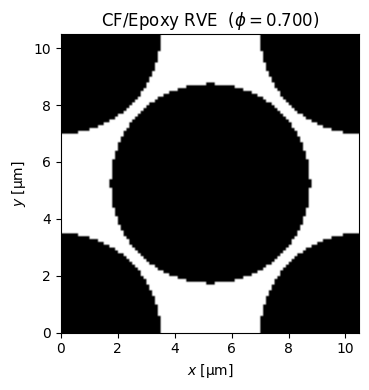

In [5]:
from IPython.display import display, Markdown

# ── Parameters ────────────────────────────────────────────────────────────────
phi        = 0.7     # target fibre volume fraction
r_fib_um   = 3.5      # fibre radius [µm]  (7 µm diameter)
vox_um     = 0.1    # physical voxel size [µm/px]

# ── Materials: 0 = epoxy matrix, 1 = carbon fibre ────────────────────────────
mats = [
    dict(E=3.5e3,  nu=0.35, name='epoxy matrix'),
    dict(E=28e3,  nu=0.23, name='carbon fibre'),
]

def lame(E, nu):
    lam = E * nu / ((1 + nu) * (1 - 2*nu))
    mu  = E / (2 * (1 + nu))
    return lam, mu

# ── Generate RVE ──────────────────────────────────────────────────────────────
phase_np, N, n, L, phi_ = make_rve(phi, r_fib_um, vox_um)
N_vox  = N * N
ndim   = 3
phase  = jnp.array(phase_np.ravel())

display(Markdown(
    f'$r = {r_fib_um}\\,\\mu\\mathrm{{m}}$'
    f' &emsp;|&emsp; $L = {L[0]:.2f}\\,\\mu\\mathrm{{m}}$'
    f' &emsp;|&emsp; Target $\\phi = {phi:.3f}$'
    f' &emsp;|&emsp; Actual $\\phi = {phi_:.3f}$'
    f' &emsp;|&emsp; $N = {N}$'
    f' &emsp;|&emsp; {vox_um:.3f} µm/px'
))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(phase_np[:, :, 0].T, origin='lower', cmap='gray_r',
          extent=[0, L[0], 0, L[1]])
ax.set_title(f'CF/Epoxy RVE  ($\\phi = {phi_:.3f}$)')
ax.set_xlabel('$x$ [µm]');  ax.set_ylabel('$y$ [µm]')
ax.set_aspect('equal')
plt.tight_layout();  plt.show()


## 2  Core Operators

In [8]:
@jit
def ddot42(A, B):
    """C_ij = A_ijkl B_kl   shapes: (3,3,3,3,N), (3,3,N) → (3,3,N)"""
    return jnp.einsum('ijklm,klm->ijm', A, B)

@jit
def fft_s(x):
    """FFT over spatial dims only. Reshapes (..., N_vox) → (..., *n) before transform."""
    shape = x.shape
    return jnp.fft.fftn(x.reshape(shape[:-1] + n), axes=(-3, -2, -1)).reshape(shape)

@jit
def ifft_s(x):
    """Inverse FFT over spatial dims only. Reshapes (..., N_vox) → (..., *n) before transform."""
    shape = x.shape
    return jnp.fft.ifftn(x.reshape(shape[:-1] + n), axes=(-3, -2, -1)).real.reshape(shape)

def isotropic_C(lam, mu):
    """(3,3,3,3) isotropic stiffness tensor."""
    d = jnp.eye(3)
    return (lam * jnp.einsum('ij,kl->ijkl', d, d)
          + mu  * (jnp.einsum('ik,jl->ijkl', d, d)
                 + jnp.einsum('il,jk->ijkl', d, d)))

# per-voxel stiffness field  (3,3,3,3, N_vox)
C_mats  = jnp.stack([isotropic_C(*lame(m['E'], m['nu'])) for m in mats], axis=-1)
C_field = C_mats[:, :, :, :, phase]     # broadcast material index → (3,3,3,3,N_vox)

# reference medium: arithmetic mean of Lamé constants
lam0 = float(phi_ * lame(mats[1]['E'], mats[1]['nu'])[0]
           + (1-phi_) * lame(mats[0]['E'], mats[0]['nu'])[0])
mu0  = float(phi_ * lame(mats[1]['E'], mats[1]['nu'])[1]
           + (1-phi_) * lame(mats[0]['E'], mats[0]['nu'])[1])
print(f'Reference medium: λ₀={lam0/1e3:.1f} GPa  μ₀={mu0/1e3:.1f} GPa')

Reference medium: λ₀=7.7 GPa  μ₀=8.4 GPa


## 3  Green's Operator $\hat{\boldsymbol{\Gamma}}_0(\boldsymbol{\xi})$

$$K^{-1}_{ij}(\boldsymbol{\xi}) = \frac{1}{\mu_0|\boldsymbol{\xi}|^2}
\!\left(\delta_{ij} - \frac{\lambda_0+\mu_0}{\lambda_0+2\mu_0}\hat{n}_i\hat{n}_j\right)
\qquad
\hat{\Gamma}_{0,ijkl} = -\tfrac{1}{4}\bigl(
K^{-1}_{ik}\hat{n}_j\hat{n}_l + \text{3 sym. terms}\bigr)$$

In [9]:
def build_freq_grid(n, L):
    freqs = [jnp.fft.fftfreq(ni, d=Li/ni) * 2*jnp.pi for ni, Li in zip(n, L)]
    xi    = jnp.stack([g.ravel() for g in jnp.meshgrid(*freqs, indexing='ij')])
    return xi   # (3, N_vox)

def build_green_operator(xi_flat, lam0, mu0):
    xi_sq  = jnp.sum(xi_flat**2, axis=0)              # (N_vox,)
    safe   = xi_sq > 0
    xi_s   = jnp.where(safe, xi_sq, 1.0)
    n_hat  = xi_flat / jnp.sqrt(xi_s)[None, :]        # (3, N_vox)

    c      = (lam0 + mu0) / (lam0 + 2*mu0)
    delta  = jnp.eye(3)

    # DBFFT / FFTMAD convention: Γ_{ijkl} = ¼(n̂_j K_eff_{ik} n̂_l + 3 sym. terms)
    # where K_eff_{ik} = (δ_{ik} - c n̂_i n̂_k) / μ₀  (no 1/|ξ|² factor).
    # This is |ξ|² × K_acoustic⁻¹ and gives A(v) ≈ v for compatible modes,
    # making the CG system well-conditioned (contrast-ratio condition number).
    # Using K_acoustic⁻¹ (with 1/|ξ|²) instead gives A ≈ (-∇²)⁻¹ v, which
    # has condition number ~|ξ|_max²/|ξ|_min² ~ N² — CG cannot converge.
    Kinv   = (delta[:,:,None]
              - c * jnp.einsum('iN,jN->ijN', n_hat, n_hat)
             ) / mu0                                   # (3,3,N_vox)

    nn     = jnp.einsum('iN,jN->ijN', n_hat, n_hat)
    Gamma  = +0.25 * (
        jnp.einsum('ikN,jlN->ijklN', Kinv, nn) +
        jnp.einsum('ilN,jkN->ijklN', Kinv, nn) +
        jnp.einsum('jkN,ilN->ijklN', Kinv, nn) +
        jnp.einsum('jlN,ikN->ijklN', Kinv, nn)
    )                                                   # (3,3,3,3,N_vox)
    return jnp.where(safe[None,None,None,None,:], Gamma, 0.0)

xi_flat = build_freq_grid(n, L)                        # (3, N_vox)
xi_sq   = jnp.sum(xi_flat**2, axis=0)                 # (N_vox,)  — kept for later
G_glob  = build_green_operator(xi_flat, lam0, mu0)    # (3,3,3,3,N_vox)
print('G_glob shape:', G_glob.shape)

G_glob shape: (3, 3, 3, 3, 11025)


## 4  Newton-CG Solve

For **linear elasticity**, Newton converges in **one step**.
The single CG system is:

$$A(\delta\boldsymbol{\varepsilon}) = \mathbf{b}$$

$$A(\delta\boldsymbol{\varepsilon}) =
\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\mathbb{C}(\mathbf{x}):\delta\boldsymbol{\varepsilon}]\bigr]$$

$$\mathbf{b} = -\mathcal{F}^{-1}\!\bigl[\hat{\boldsymbol{\Gamma}}_0 :
\mathcal{F}[\boldsymbol{\sigma}^{(0)} - \boldsymbol{\sigma}^\text{goal}]\bigr]$$

with initial guess $\boldsymbol{\varepsilon}^{(0)} = \bar{\boldsymbol{\varepsilon}}$
(uniform strain) and $\boldsymbol{\sigma}^\text{goal} = \mathbf{0}$.

In [10]:
def make_A_operator(G_glob, C_field):
    """Matrix-free operator  A(δε) = IFFT[ Γ̂₀ : FFT[ C : δε ] ]."""
    shape = (3, 3, N_vox)

    @jit
    def A_op(v_flat):
        v      = v_flat.reshape(shape)
        Cv     = ddot42(C_field, v)          # C(x) : δε   (3,3,N_vox)
        Cv_ft  = fft_s(Cv)                   # FFT
        out_ft = ddot42(G_glob, Cv_ft)       # Γ̂₀ : ...
        return ifft_s(out_ft).reshape(-1)    # real, flat
    return A_op

@jit
def build_rhs(G_glob, stress_res):
    """b = -IFFT[ Γ̂₀ : FFT[ σ_res ] ]  →  flat vector."""
    return -ifft_s(ddot42(G_glob, fft_s(stress_res))).reshape(-1)

@partial(jit, static_argnames=('maxiter',))
def solve_elastic(G_glob, C_field, eps_bar, stress_goal,
                  toler_lin=1e-10, maxiter=1000):
    """
    Newton-CG elastic solve.

    eps_bar      : (3,3)       prescribed macroscopic strain
    stress_goal  : (3,3,N_vox) target stress (zero for strain control)
    Returns      : eps (3,3,N_vox),  sigma (3,3,N_vox),  cg_info
    """
    # initial guess: uniform strain
    eps0   = jnp.ones((3, 3, N_vox)) * eps_bar[:, :, None]   # (3,3,N_vox)
    sigma0 = ddot42(C_field, eps0)                            # (3,3,N_vox)

    # RHS: stress residual from initial guess
    stress_res = sigma0 - stress_goal
    bb         = build_rhs(G_glob, stress_res)                # (9*N_vox,)
    bbn        = jnp.linalg.norm(bb)

    # skip solve if residual already tiny
    tol = jnp.maximum(toler_lin, toler_lin * 1.0 / (bbn + 1e-300))

    # matrix-free operator
    A_op = make_A_operator(G_glob, C_field)

    # CG solve
    x0            = jnp.zeros_like(bb)
    delta_flat, info = jax_cg(A_op, bb, x0=x0,
                               tol=toler_lin, maxiter=maxiter)

    # update strain and stress
    eps   = eps0 + delta_flat.reshape(3, 3, N_vox)
    sigma = ddot42(C_field, eps)
    return eps, sigma, info

print('Functions defined.')

Functions defined.


In [11]:
def solve_homogenization(n_i, C_field, G_glob, eps_bar,
                         tol=1e-10, maxiter=2000):
    """
    Newton-CG elastic FFT solve for any grid shape n_i.

    Handles variable N without JIT shape conflicts — use this in loops
    where n changes.  For a fixed-shape hot loop use solve_elastic instead.

    Parameters
    ----------
    n_i     : tuple          grid shape, e.g. (64, 64, 1)
    C_field : (3,3,3,3,Nv)  per-voxel stiffness field
    G_glob  : (3,3,3,3,Nv)  Green\'s operator
    eps_bar : (3,3)          prescribed macroscopic strain
    tol     : float          CG relative tolerance   (default 1e-10)
    maxiter : int            max CG iterations        (default 2000)

    Returns
    -------
    eps   : (3,3,Nv)  strain field
    sigma : (3,3,Nv)  stress field
    info  : int        0 = converged, >0 = not converged within maxiter
    """
    Nv = int(np.prod(n_i))

    def fft_(x,  _n=n_i): s=x.shape; return jnp.fft.fftn( x.reshape(s[:-1]+_n),axes=(-3,-2,-1)).reshape(s)
    def ifft_(x, _n=n_i): s=x.shape; return jnp.fft.ifftn(x.reshape(s[:-1]+_n),axes=(-3,-2,-1)).real.reshape(s)

    def A_op(v_flat, _C=C_field, _G=G_glob, _Nv=Nv, _f=fft_, _if=ifft_):
        v = v_flat.reshape(3, 3, _Nv)
        return _if(jnp.einsum('ijklm,klm->ijm', _G,
                   _f(jnp.einsum('ijklm,klm->ijm', _C, v)))).reshape(-1)

    eps0   = jnp.ones((3, 3, Nv)) * eps_bar[:, :, None]
    sigma0 = jnp.einsum('ijklm,klm->ijm', C_field, eps0)
    bb     = -ifft_(jnp.einsum('ijklm,klm->ijm', G_glob, fft_(sigma0))).reshape(-1)

    delta, info = jax_cg(A_op, bb, tol=tol, maxiter=maxiter)

    eps   = eps0 + delta.reshape(3, 3, Nv)
    sigma = jnp.einsum('ijklm,klm->ijm', C_field, eps)
    return eps, sigma, info


print('solve_homogenization defined — signature: (n_i, C_field, G_glob, eps_bar, tol=1e-10, maxiter=2000)')


solve_homogenization defined — signature: (n_i, C_field, G_glob, eps_bar, tol=1e-10, maxiter=2000)


## 5  Run — Uniaxial Tension $\bar{\varepsilon}_{11} = 10^{-3}$

In [21]:
import time

eps_bar     = jnp.zeros((3, 3)).at[1, 1].set(1e-3)   # ε̄₁₁ = 0.001
stress_goal = jnp.zeros((3, 3, N_vox))

# first call — JIT compile
print('Tracing...')
t0 = time.perf_counter()
eps, sigma, info = solve_elastic(G_glob, C_field, eps_bar, stress_goal)
jax.block_until_ready((eps, sigma))
t_compile = time.perf_counter() - t0

# second call — compiled kernel
t0 = time.perf_counter()
eps, sigma, info = solve_elastic(G_glob, C_field, eps_bar, stress_goal)
jax.block_until_ready((eps, sigma))
t_run = time.perf_counter() - t0

print(f'Compile: {t_compile:.3f}s  |  Run: {t_run*1000:.2f}ms  |  CG info: {info}')

print(eps.mean(axis=-1))

print(sigma.mean(axis=-1))

Tracing...
Compile: 0.143s  |  Run: 159.25ms  |  CG info: None
[[9.59801651e-21 1.20761929e-20 0.00000000e+00]
 [2.04154532e-20 1.00000000e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
[[7.09695922e+00 3.69224429e-15 0.00000000e+00]
 [3.69224429e-15 1.49197287e+01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.68701622e+00]]


## 6  Verification

In [22]:
# --- mean strain matches prescribed ---
eps_mean = jnp.mean(eps, axis=-1)
print('Mean strain error:', float(jnp.max(jnp.abs(eps_mean - eps_bar))))

# --- stress equilibrium: ∇·σ ≈ 0 ---
sigma_ft  = fft_s(sigma)
div_sigma = jnp.zeros((3, N_vox), dtype=complex)
for i in range(3):
    for j in range(3):
        div_sigma = div_sigma.at[i].add(1j * xi_flat[j] * sigma_ft[i, j])
div_real  = jnp.fft.ifftn(div_sigma.reshape(3, *n), axes=(-3,-2,-1)).real

sigma_ref = float(jnp.linalg.norm(jnp.mean(sigma, axis=-1)))
equil_err = float(jnp.linalg.norm(div_real)) / (sigma_ref * N_vox**0.5)
print(f'Equilibrium residual: {equil_err:.2e}  (should be < tol)')

# --- macroscopic C₁₁₁₁_eff (uniaxial strain: ε̄₂₂ = ε̄₃₃ = 0) ---
sigma_bar  = jnp.mean(sigma, axis=-1)
C1111_eff  = float(sigma_bar[1,1]) / float(eps_bar[1,1])

def c1111(E, nu):
    lam, mu = lame(E, nu)
    return lam + 2*mu



# --- Schürmann semi-empirical E₂ (transverse Young's modulus, uniaxial stress) ---
# Schürmann, "Konstruieren mit FKV", formula for transverse modulus E_⊥
Em_ps   = mats[0]['E'] / (1 - mats[0]['nu']**2)    # matrix plane-strain modulus
E2_semi = Em_ps * (1 + 0.85*phi_**2) / ((1 - phi_)**1.25 + Em_ps / mats[1]['E'] * phi_)

rel_err = (C1111_eff - E2_semi) / C1111_eff * 100   # % by which FFT exceeds Schürmann

display(Markdown(f"""
| Quantity | Value |
|---|---|
| FFT $C_{{1111}}^{{\\rm eff}}$ (uniaxial strain) | **{C1111_eff/1e3:.2f} GPa** |
| Schürmann $E_\\perp$ (uniaxial stress) | **{E2_semi/1e3:.2f} GPa** |
| Relative error $(C_{{1111}} - E_\\perp)/C_{{1111}}$ | **{rel_err:.1f} %** |
"""))


Mean strain error: 4.336808689942018e-19
Equilibrium residual: 1.27e-09  (should be < tol)



| Quantity | Value |
|---|---|
| FFT $C_{1111}^{\rm eff}$ (uniaxial strain) | **14.92 GPa** |
| Schürmann $E_\perp$ (uniaxial stress) | **17.54 GPa** |
| Relative error $(C_{1111} - E_\perp)/C_{1111}$ | **-17.5 %** |


## 7  Field Plots

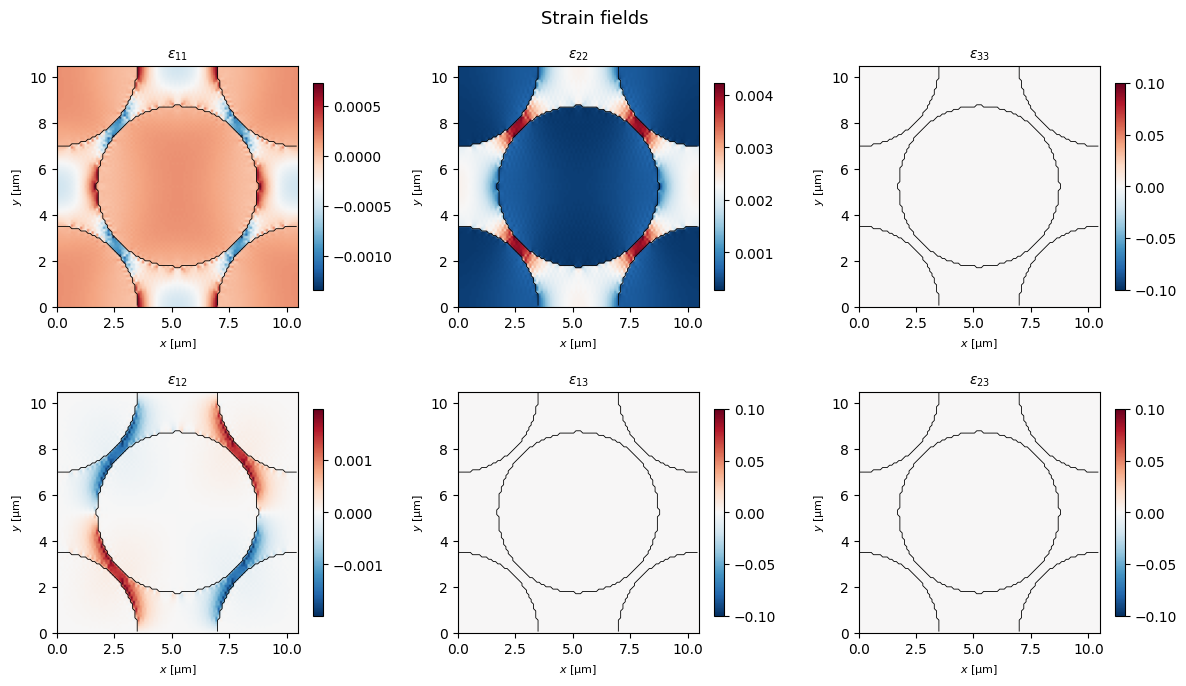

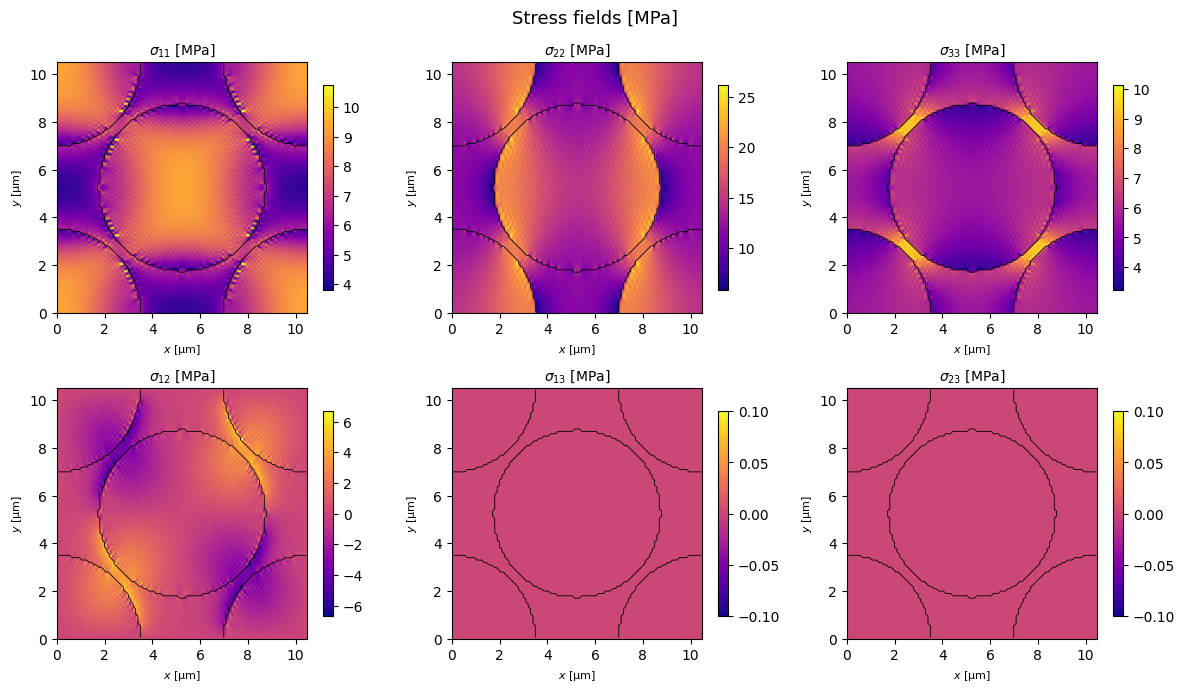

In [23]:
def field2d(arr_flat, component, title, ax, cmap='RdBu_r'):
    """Plot one tensor component on a given Axes."""
    i, j = component
    data = np.array(arr_flat[i, j, :].reshape(N, N))
    im = ax.imshow(data.T, origin='lower', cmap=cmap,
                   extent=[0, L[0], 0, L[1]])
    ax.contour(phase_np[:, :, 0].T, levels=[0.5], colors='k',
               linewidths=0.6, origin='lower', extent=[0, L[0], 0, L[1]])
    plt.colorbar(im, ax=ax, shrink=0.75)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$ [µm]', fontsize=8)
    ax.set_ylabel('$y$ [µm]', fontsize=8)
    ax.set_aspect('equal')

# symmetric tensor components in Voigt order (normal first, then shear)
strain_comps = [
    ((0,0), r'$\varepsilon_{11}$'), ((1,1), r'$\varepsilon_{22}$'), ((2,2), r'$\varepsilon_{33}$'),
    ((0,1), r'$\varepsilon_{12}$'), ((0,2), r'$\varepsilon_{13}$'), ((1,2), r'$\varepsilon_{23}$'),
]
stress_comps = [
    ((0,0), r'$\sigma_{11}$ [MPa]'), ((1,1), r'$\sigma_{22}$ [MPa]'), ((2,2), r'$\sigma_{33}$ [MPa]'),
    ((0,1), r'$\sigma_{12}$ [MPa]'), ((0,2), r'$\sigma_{13}$ [MPa]'), ((1,2), r'$\sigma_{23}$ [MPa]'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (comp, title) in zip(axes.ravel(), strain_comps):
    field2d(eps, comp, title, ax, cmap='RdBu_r')
fig.suptitle('Strain fields', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (comp, title) in zip(axes.ravel(), stress_comps):
    field2d(sigma, comp, title, ax, cmap='plasma')
fig.suptitle('Stress fields [MPa]', fontsize=13)
plt.tight_layout()
plt.show()


## 8  Load Stepping — Stress–Strain Curve

Prescribe increasing $\bar{\varepsilon}_{11}$ and compute macroscopic $\bar{\sigma}_{11}$
(linear elastic → straight line, slope = $E_\text{eff}$).

In [ ]:
n_steps  = 10
eps_max  = 5e-3
eps_vals = np.linspace(0, eps_max, n_steps + 1)[1:]

C1111_list = []
for e11 in eps_vals:
    eps_bar_i = jnp.zeros((3,3)).at[0,0].set(e11)
    _, sigma_i, _ = solve_elastic(G_glob, C_field, eps_bar_i, stress_goal)
    C1111_list.append(float(jnp.mean(sigma_i[0,0,:])) / e11)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(eps_vals * 100, [c * e for c, e in zip(C1111_list, eps_vals)],
        'o-', label=f'FFT  $C_{{1111}}^{{\\rm eff}}={C1111_eff/1e3:.1f}$ GPa')

ax.set_xlabel(r'$\bar{\varepsilon}_{11}$ [%]')
ax.set_ylabel(r'$\bar{\sigma}_{11}$ [MPa]')
ax.set_title('Macroscopic stress–strain (linear elastic)')
ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

# 8 Loop over $\phi$

[ 1/10]  phi=0.300  N=161  C1111=7.83  nu=0.343   E2_sch=6.29 GPa
[ 2/10]  phi=0.350  N=149  C1111=8.32  nu=0.342   E2_sch=6.96 GPa
[ 3/10]  phi=0.400  N=139  C1111=8.87  nu=0.342   E2_sch=7.74 GPa
[ 4/10]  phi=0.450  N=131  C1111=9.49  nu=0.341   E2_sch=8.69 GPa
[ 5/10]  phi=0.500  N=125  C1111=10.20  nu=0.340   E2_sch=9.83 GPa
[ 6/10]  phi=0.550  N=119  C1111=11.04  nu=0.338   E2_sch=11.23 GPa
[ 7/10]  phi=0.600  N=114  C1111=12.05  nu=0.335   E2_sch=12.91 GPa
[ 8/10]  phi=0.650  N=109  C1111=13.29  nu=0.330   E2_sch=14.98 GPa
[ 9/10]  phi=0.700  N=105  C1111=14.92  nu=0.322   E2_sch=17.54 GPa
[10/10]  phi=0.750  N=102  C1111=17.16  nu=0.308   E2_sch=20.77 GPa


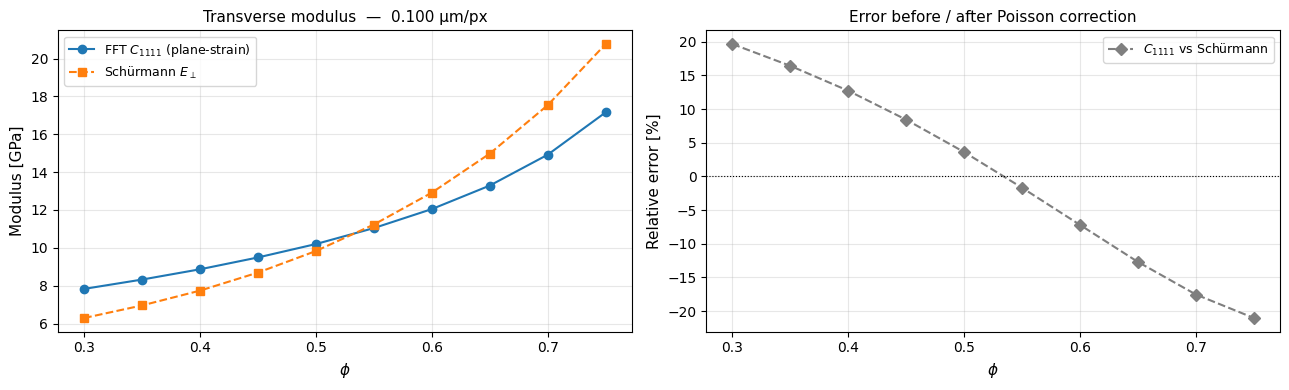

In [24]:
# ── Phi sweep — fixed physical voxel size ────────────────────────────────────
phi_range    = np.linspace(0.3, 0.75, 10)
eps_bar_loop = jnp.zeros((3, 3)).at[0, 0].set(1e-3)

C1111_fft = []

E2_schurm = []
nu_list   = []

for k, phi_i in enumerate(phi_range):
    phase_i_np, N_i, n_i, L_i_tup, phi_act = make_rve(phi_i, r_fib_um, vox_um)
    Nv_i    = N_i * N_i
    phase_i = jnp.array(phase_i_np.ravel())

    C_mats_i  = jnp.stack([isotropic_C(*lame(m['E'], m['nu'])) for m in mats], axis=-1)
    C_field_i = C_mats_i[:, :, :, :, phase_i]
    lam0_i = phi_act*lame(mats[1]['E'],mats[1]['nu'])[0] + (1-phi_act)*lame(mats[0]['E'],mats[0]['nu'])[0]
    mu0_i  = phi_act*lame(mats[1]['E'],mats[1]['nu'])[1] + (1-phi_act)*lame(mats[0]['E'],mats[0]['nu'])[1]

    xi_i = build_freq_grid(n_i, L_i_tup)
    G_i  = build_green_operator(xi_i, lam0_i, mu0_i)

    eps_i, sigma_i, _ = solve_homogenization(n_i, C_field_i, G_i, eps_bar_loop)

    sbar = jnp.mean(sigma_i, axis=-1)
    C11  = float(sbar[0, 0]) / 1e-3
    C12  = float(sbar[1, 1]) / 1e-3
    nu   = C12 / (C11 + C12)                          # true 3-D ν_eff


    C1111_fft.append(C11)

    nu_list.append(nu)

    Em_ps = mats[0]['E'] / (1 - mats[0]['nu']**2)
    E2_schurm.append(Em_ps*(1+0.85*phi_act**2) / ((1-phi_act)**1.25 + Em_ps/mats[1]['E']*phi_act))

    print(f'[{k+1:2d}/{len(phi_range)}]  phi={phi_act:.3f}  N={N_i:3d}  '
          f'C1111={C11/1e3:.2f}  nu={nu:.3f}   E2_sch={E2_schurm[-1]/1e3:.2f} GPa')

# ── relative errors ───────────────────────────────────────────────────────────
err_C11 = [(c - s) / c * 100 for c, s in zip(C1111_fft, E2_schurm)]


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(phi_range, [v/1e3 for v in C1111_fft], 'o-',  label=r'FFT $C_{1111}$ (plane-strain)')
ax1.plot(phi_range, [v/1e3 for v in E2_schurm], 's--', label=r'Schürmann $E_\perp$')
ax1.set_xlabel(r'$\phi$', fontsize=11);  ax1.set_ylabel('Modulus [GPa]', fontsize=11)
ax1.set_title(fr'Transverse modulus  —  {vox_um:.3f} µm/px', fontsize=11)
ax1.legend(fontsize=9);  ax1.grid(True, alpha=0.3)

ax2.plot(phi_range, err_C11, 'D--', color='tab:gray',   label=r'$C_{1111}$ vs Schürmann')
ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.set_xlabel(r'$\phi$', fontsize=11);  ax2.set_ylabel('Relative error [%]', fontsize=11)
ax2.set_title('Error before / after Poisson correction', fontsize=11)
ax2.legend(fontsize=9);  ax2.grid(True, alpha=0.3)

plt.tight_layout();  plt.show()
